In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator

# ── 1. Download data ──────────────────────────────────────────
data = yf.download("BTC-USD", period="3y", auto_adjust=True)

# ── 2. Flatten MultiIndex columns IMMEDIATELY after download ──
data.columns = data.columns.get_level_values(0)
print("Columns after fix:", data.columns.tolist())
# Should print: ['Close', 'High', 'Low', 'Open', 'Volume']

# ── 3. Extract clean Close series ────────────────────────────
close = data['Close'].squeeze()

# ── 4. Add technical indicators ──────────────────────────────
data['RSI']   = RSIIndicator(close=close).rsi()
macd          = MACDIndicator(close=close)
data['MACD']  = macd.macd()
data['MA_10'] = close.rolling(window=10).mean()
data['MA_50'] = close.rolling(window=50).mean()

# ── 5. Add target column ──────────────────────────────────────
data['Future_Close'] = close.shift(-1)
data['Target'] = (data['Future_Close'] > close).astype(int)

# ── 6. Build X and y, drop NaN rows ──────────────────────────
features = ['Close', 'RSI', 'MACD', 'MA_10', 'MA_50']
data.dropna(inplace=True)

X = data[features]
y = data['Target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaN in X?", X.isnull().any().any())  # must be False
print("\n", X.tail())
print("\n", y.tail())

/Users/myapple/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

Columns after fix: ['Close', 'High', 'Low', 'Open', 'Volume']
X shape: (1047, 5)
y shape: (1047,)
Any NaN in X? False

 Price              Close        RSI         MACD         MA_10         MA_50
Date                                                                        
2026-04-13  74484.640625  62.192425   911.876795  71123.550000  69279.078281
2026-04-14  74181.609375  61.135084  1086.866277  71812.659375  69470.375703
2026-04-15  74805.078125  62.545958  1261.315756  72394.977344  69684.876406
2026-04-16  75152.132812  63.343672  1411.304004  73024.207812  69828.716563
2026-04-17  77126.875000  67.575424  1670.262219  73542.825000  70022.178594

 Date
2026-04-13    0
2026-04-14    1
2026-04-15    1
2026-04-16    1
2026-04-17    0
Name: Target, dtype: int64


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

print("Training samples:", X_train.shape[0])
print("Test samples:    ", X_test.shape[0])

Training samples: 837
Test samples:     210


In [3]:
from sklearn.ensemble import RandomForestClassifier
import joblib

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Save the model and scaler so the web app can load them
joblib.dump(model, 'crypto_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model saved!")

Model saved!


Accuracy: 45.24 %

               precision    recall  f1-score   support

        DOWN       0.47      0.34      0.39       110
          UP       0.44      0.58      0.50       100

    accuracy                           0.45       210
   macro avg       0.46      0.46      0.45       210
weighted avg       0.46      0.45      0.44       210



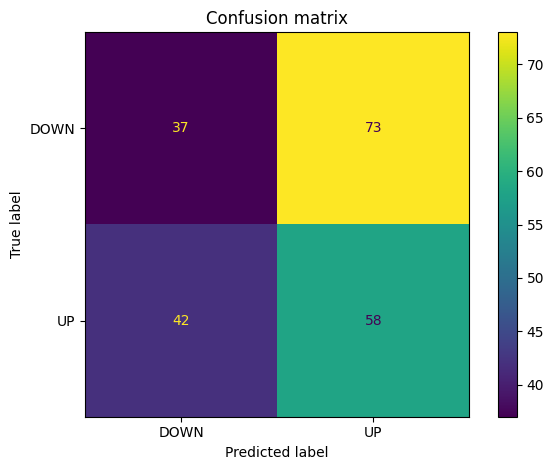

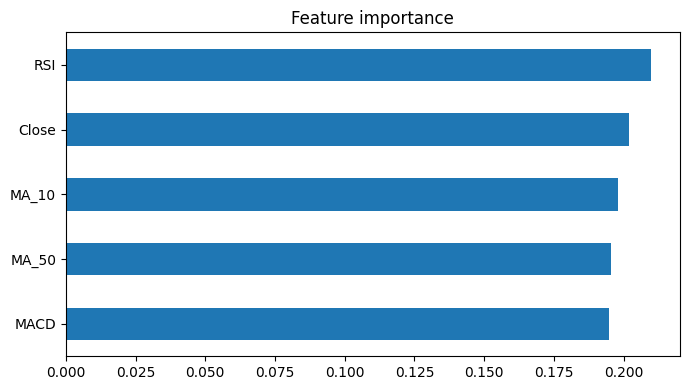

In [4]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\n", classification_report(y_test, y_pred, target_names=["DOWN", "UP"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["DOWN", "UP"])
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

# Feature importance
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
feat_imp.plot(kind='barh', title='Feature importance', figsize=(7,4))
plt.tight_layout()
plt.show()

In [6]:
import sys
!{sys.executable} -m pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.1 MB 959 kB/s eta 0:00:01
     |████████████████████████████████| 731 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 9.3 MB/s  eta 0:00:01
     |████████████████████████████████| 208 kB 9.3 MB/s eta 0:00:01
     |████████████████████████████████| 32.7 MB 154 kB/s eta 0:00:01
     |████████████████████████████████| 11.3 MB 10.6 MB/s eta 0:00:01
     |████████████████████████████████| 66 kB 774 kB/s eta 0:00:011
     |████████████████████████████████| 446 kB 12.4 MB/s eta 0:00:01
  Using cached jsonschema-4.25.1-py3-none-any.whl (90 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
     |████████████████████████████████| 62 kB 3.7 MB/s  eta 0:00:01
  Using cached referencing-0.36.2-py3-none-any.whl (26 kB)
  Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
  Using cached rpds_py-0.27.1-cp39-cp39-macosx_10_12_x86_64.whl (372 kB)
  Using 

In [8]:
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator

model  = joblib.load('crypto_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("Crypto price movement predictor")
st.write("Predicts whether tomorrow's price will go UP or DOWN.")

ticker = st.selectbox("Choose a coin", ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD"])

if st.button("Predict"):
    with st.spinner("Fetching data..."):
        df = yf.download(ticker, period="3mo", auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        close = df['Close'].squeeze()

        df['RSI']   = RSIIndicator(close=close).rsi()
        macd        = MACDIndicator(close=close)
        df['MACD']  = macd.macd()
        df['MA_10'] = close.rolling(10).mean()
        df['MA_50'] = close.rolling(50).mean()
        df.dropna(inplace=True)

        features = ['Close', 'RSI', 'MACD', 'MA_10', 'MA_50']
        latest = df[features].iloc[[-1]]
        scaled = scaler.transform(latest)
        pred   = model.predict(scaled)[0]
        prob   = model.predict_proba(scaled)[0]

        st.metric("Current price", f"${close.iloc[-1]:,.2f}")

        if pred == 1:
            st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        else:
            st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")

2026-04-19 00:44:31.421 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.461 
  command:

    streamlit run /Users/myapple/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-19 00:44:31.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.464 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-19 00:44:31.465 Thread 

In [11]:
import os
print(os.getcwd())

/Users/myapple/crypto-ml-project


In [12]:
import os
import shutil

# Remove the wrongly created app.py folder
shutil.rmtree('app.py')

# Save the real app.py file
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator

model  = joblib.load('crypto_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("Crypto price movement predictor")
st.write("Predicts whether tomorrow's price will go UP or DOWN.")

ticker = st.selectbox("Choose a coin", ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD"])

if st.button("Predict"):
    with st.spinner("Fetching data..."):
        df = yf.download(ticker, period="3mo", auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        close = df["Close"].squeeze()

        df["RSI"]   = RSIIndicator(close=close).rsi()
        macd        = MACDIndicator(close=close)
        df["MACD"]  = macd.macd()
        df["MA_10"] = close.rolling(10).mean()
        df["MA_50"] = close.rolling(50).mean()
        df.dropna(inplace=True)

        features = ["Close", "RSI", "MACD", "MA_10", "MA_50"]
        latest = df[features].iloc[[-1]]
        scaled = scaler.transform(latest)
        pred   = model.predict(scaled)[0]
        prob   = model.predict_proba(scaled)[0]

        st.metric("Current price", f"${close.iloc[-1]:,.2f}")

        if pred == 1:
            st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        else:
            st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py saved successfully!")
print("Saved to:", os.path.abspath('app.py'))

app.py saved successfully!
Saved to: /Users/myapple/crypto-ml-project/app.py


In [13]:
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
yfinance
scikit-learn
ta
pandas
numpy
joblib
""")
print("requirements.txt saved!")

requirements.txt saved!


In [14]:
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator

model  = joblib.load("crypto_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Crypto price movement predictor")
st.write("Predicts whether tomorrow's price will go UP or DOWN.")

ticker = st.selectbox("Choose a coin", [
    "BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD",
    "XRP-USD", "ADA-USD", "DOGE-USD", "AVAX-USD"
])

if st.button("Predict"):
    with st.spinner("Fetching live data..."):
        df = yf.download(ticker, period="3mo", auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        close = df["Close"].squeeze()

        df["RSI"]   = RSIIndicator(close=close).rsi()
        macd        = MACDIndicator(close=close)
        df["MACD"]  = macd.macd()
        df["MA_10"] = close.rolling(10).mean()
        df["MA_50"] = close.rolling(50).mean()
        df.dropna(inplace=True)

        features = ["Close", "RSI", "MACD", "MA_10", "MA_50"]
        latest = df[features].iloc[[-1]]
        scaled = scaler.transform(latest)
        pred   = model.predict(scaled)[0]
        prob   = model.predict_proba(scaled)[0]
        confidence = max(prob)

        st.metric("Current price", f"${close.iloc[-1]:,.2f}")
        st.write("---")

        if confidence < 0.65:
            st.warning(f"Model confidence is only {round(confidence*100)}% — not confident enough to predict today. Try again tomorrow.")
        elif pred == 1:
            st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        else:
            st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")

        st.write("---")
        st.subheader("Recent price trend")
        st.line_chart(df["Close"].tail(30))

        st.subheader("Last 5 days indicators")
        st.dataframe(df[["Close", "RSI", "MACD", "MA_10", "MA_50"]].tail())
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py updated successfully!")

app.py updated successfully!


In [15]:
import sys
!{sys.executable} -m pip install newsapi-python textblob

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 624 kB 341 kB/s eta 0:00:01
     |████████████████████████████████| 1.5 MB 10.1 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 4.5 MB/s eta 0:00:01
     |████████████████████████████████| 290 kB 4.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [16]:
import sys
!{sys.executable} -m pip install newsapi-python textblob python-dotenv

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [17]:
with open(".env", "w") as f:
    f.write('NEWS_API_KEY="937a467b63604aeab7e711f7103c0448"\n')

print(".env file created!")

.env file created!


In [18]:
with open(".gitignore", "w") as f:
    f.write(".env\n")
    f.write("*.pkl\n")

print(".gitignore created!")

.gitignore created!


In [19]:
from newsapi import NewsApiClient
from textblob import TextBlob
from dotenv import load_dotenv
import os

load_dotenv()
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

def get_sentiment(coin_name):
    newsapi = NewsApiClient(api_key=NEWS_API_KEY)
    articles = newsapi.get_everything(
        q=coin_name,
        language="en",
        sort_by="publishedAt",
        page_size=10
    )
    headlines = [a["title"] for a in articles["articles"]]
    if not headlines:
        return 0, "Neutral", []
    scores = [TextBlob(h).sentiment.polarity for h in headlines]
    avg = sum(scores) / len(scores)
    mood = "Positive" if avg > 0.1 else "Negative" if avg < -0.1 else "Neutral"
    return round(avg, 3), mood, headlines[:3]

score, mood, headlines = get_sentiment("Bitcoin")
print("Sentiment score:", score)
print("Market mood:", mood)
print("\nTop 3 headlines:")
for h in headlines:
    print("-", h)

Sentiment score: 0.026
Market mood: Neutral

Top 3 headlines:
- Crypto News: Pepeto Presale Crosses $9.17 Million Whilst Bitcoin Price Prediction Targets New ATH and Ethereum Price Surge Ahead Of Bull Run
- Bitcoin whale accumulation rises as exchange reserves fall sharply
- Aave Is Trading Like 2022 Again: Danger Zone Or Entry Point?


In [20]:
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
import os
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator
from newsapi import NewsApiClient
from textblob import TextBlob
from dotenv import load_dotenv

load_dotenv()
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

model  = joblib.load("crypto_model.pkl")
scaler = joblib.load("scaler.pkl")

COIN_NAMES = {
    "BTC-USD": "Bitcoin",
    "ETH-USD": "Ethereum",
    "BNB-USD": "Binance coin",
    "SOL-USD": "Solana",
    "XRP-USD": "XRP",
    "ADA-USD": "Cardano",
    "DOGE-USD": "Dogecoin",
    "AVAX-USD": "Avalanche"
}

def get_sentiment(coin_name):
    try:
        newsapi = NewsApiClient(api_key=NEWS_API_KEY)
        articles = newsapi.get_everything(
            q=coin_name,
            language="en",
            sort_by="publishedAt",
            page_size=10
        )
        headlines = [a["title"] for a in articles["articles"]]
        if not headlines:
            return 0, "Neutral", []
        scores = [TextBlob(h).sentiment.polarity for h in headlines]
        avg = sum(scores) / len(scores)
        mood = "Positive" if avg > 0.1 else "Negative" if avg < -0.1 else "Neutral"
        return round(avg, 3), mood, headlines[:3]
    except:
        return 0, "Unavailable", []

st.title("Crypto price movement predictor")
st.write("Predicts whether tomorrow's price will go UP or DOWN.")

ticker = st.selectbox("Choose a coin", list(COIN_NAMES.keys()))

if st.button("Predict"):
    with st.spinner("Fetching live data and news..."):
        df = yf.download(ticker, period="3mo", auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        close = df["Close"].squeeze()

        df["RSI"]   = RSIIndicator(close=close).rsi()
        macd        = MACDIndicator(close=close)
        df["MACD"]  = macd.macd()
        df["MA_10"] = close.rolling(10).mean()
        df["MA_50"] = close.rolling(50).mean()
        df.dropna(inplace=True)

        features = ["Close", "RSI", "MACD", "MA_10", "MA_50"]
        latest = df[features].iloc[[-1]]
        scaled = scaler.transform(latest)
        pred   = model.predict(scaled)[0]
        prob   = model.predict_proba(scaled)[0]
        confidence = max(prob)

        coin_name = COIN_NAMES[ticker]
        sentiment_score, mood, headlines = get_sentiment(coin_name)

        st.metric("Current price", f"${close.iloc[-1]:,.2f}")
        st.write("---")

        if confidence < 0.65:
            st.warning(f"Model confidence is only {round(confidence*100)}% — not confident enough to predict today. Try again tomorrow.")
        elif pred == 1:
            st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        else:
            st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")

        st.write("---")
        st.subheader("News sentiment")
        col1, col2 = st.columns(2)
        col1.metric("Sentiment score", sentiment_score)
        col2.metric("Market mood", mood)

        if headlines:
            st.write("Latest headlines:")
            for h in headlines:
                st.write(f"- {h}")

        st.write("---")
        st.subheader("Recent price trend")
        st.line_chart(df["Close"].tail(30))

        st.subheader("Last 5 days indicators")
        st.dataframe(df[["Close", "RSI", "MACD", "MA_10", "MA_50"]].tail())
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py updated with sentiment analysis!")

app.py updated with sentiment analysis!


In [21]:
import os

# Check current directory
print("Current directory:", os.getcwd())

# Search for the pkl files
for root, dirs, files in os.walk("/Users/myapple"):
    for file in files:
        if file.endswith(".pkl"):
            print("Found:", os.path.join(root, file))

Current directory: /Users/myapple/crypto-ml-project
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/numpy/_core/tests/data/astype_copy.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.10.0_pickle_py33_np18.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.9.2_pickle_py27_np16.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.9.2_pickle_py27_np17.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.9.2_pickle_py34_np19.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.9.2_pickle_py35_np19.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.11.0_pickle_py36_np111.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/joblib/test/data/joblib_0.9.2_pickle_py33_np18.pkl
Found: /Users/myapple/crypto_env/lib/python3.9/site-packages/

In [23]:
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
import os
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator
from newsapi import NewsApiClient
from textblob import TextBlob
from dotenv import load_dotenv

BASE_DIR = "/Users/myapple/crypto-ml-project"
load_dotenv(os.path.join(BASE_DIR, ".env"))
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

model  = joblib.load(os.path.join(BASE_DIR, "crypto_model.pkl"))
scaler = joblib.load(os.path.join(BASE_DIR, "scaler.pkl"))

COIN_NAMES = {
    "BTC-USD": "Bitcoin",
    "ETH-USD": "Ethereum",
    "BNB-USD": "Binance coin",
    "SOL-USD": "Solana",
    "XRP-USD": "XRP",
    "ADA-USD": "Cardano",
    "DOGE-USD": "Dogecoin",
    "AVAX-USD": "Avalanche"
}

def get_sentiment(coin_name):
    try:
        newsapi = NewsApiClient(api_key=NEWS_API_KEY)
        articles = newsapi.get_everything(
            q=coin_name,
            language="en",
            sort_by="publishedAt",
            page_size=10
        )
        headlines = [a["title"] for a in articles["articles"]]
        if not headlines:
            return 0, "Neutral", []
        scores = [TextBlob(h).sentiment.polarity for h in headlines]
        avg = sum(scores) / len(scores)
        mood = "Positive" if avg > 0.1 else "Negative" if avg < -0.1 else "Neutral"
        return round(avg, 3), mood, headlines[:3]
    except:
        return 0, "Unavailable", []

st.title("Crypto price movement predictor")
st.write("Predicts whether tomorrow's price will go UP or DOWN.")

ticker = st.selectbox("Choose a coin", list(COIN_NAMES.keys()))

if st.button("Predict"):
    with st.spinner("Fetching live data and news..."):
        df = yf.download(ticker, period="3mo", auto_adjust=True)
        df.columns = df.columns.get_level_values(0)
        close = df["Close"].squeeze()

        df["RSI"]   = RSIIndicator(close=close).rsi()
        macd        = MACDIndicator(close=close)
        df["MACD"]  = macd.macd()
        df["MA_10"] = close.rolling(10).mean()
        df["MA_50"] = close.rolling(50).mean()
        df.dropna(inplace=True)

        features = ["Close", "RSI", "MACD", "MA_10", "MA_50"]
        latest = df[features].iloc[[-1]]
        scaled = scaler.transform(latest)
        pred   = model.predict(scaled)[0]
        prob   = model.predict_proba(scaled)[0]
        confidence = max(prob)

        coin_name = COIN_NAMES[ticker]
        sentiment_score, mood, headlines = get_sentiment(coin_name)

        st.metric("Current price", f"${close.iloc[-1]:,.2f}")
        st.write("---")

        if confidence < 0.65:
            st.warning(f"Model confidence is only {round(confidence*100)}% — not confident enough to predict today. Try again tomorrow.")
        elif pred == 1:
            st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        else:
            st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")

        st.write("---")
        st.subheader("News sentiment")
        col1, col2 = st.columns(2)
        col1.metric("Sentiment score", sentiment_score)
        col2.metric("Market mood", mood)

        if headlines:
            st.write("Latest headlines:")
            for h in headlines:
                st.write(f"- {h}")

        st.write("---")
        st.subheader("Recent price trend")
        st.line_chart(df["Close"].tail(30))

        st.subheader("Last 5 days indicators")
        st.dataframe(df[["Close", "RSI", "MACD", "MA_10", "MA_50"]].tail())
'''

with open("/Users/myapple/crypto-ml-project/app.py", "w") as f:
    f.write(app_code)

print("app.py updated with full paths!")

app.py updated with full paths!


In [24]:
app_code = '''
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import joblib
import os
import time
from ta.momentum import RSIIndicator
from ta.trend import MACD as MACDIndicator
from newsapi import NewsApiClient
from textblob import TextBlob
from dotenv import load_dotenv

BASE_DIR = "/Users/myapple/crypto-ml-project"
load_dotenv(os.path.join(BASE_DIR, ".env"))
NEWS_API_KEY = os.getenv("NEWS_API_KEY")

model  = joblib.load(os.path.join(BASE_DIR, "crypto_model.pkl"))
scaler = joblib.load(os.path.join(BASE_DIR, "scaler.pkl"))

COIN_NAMES = {
    "BTC-USD": "Bitcoin",
    "ETH-USD": "Ethereum",
    "BNB-USD": "Binance coin",
    "SOL-USD": "Solana",
    "XRP-USD": "XRP",
    "ADA-USD": "Cardano",
    "DOGE-USD": "Dogecoin",
    "AVAX-USD": "Avalanche"
}

UP_SOUND = """
<script>
function playUpSound() {
    const ctx = new AudioContext();
    const frequencies = [523, 659, 784];
    frequencies.forEach((freq, i) => {
        const osc = ctx.createOscillator();
        const gain = ctx.createGain();
        osc.connect(gain);
        gain.connect(ctx.destination);
        osc.frequency.value = freq;
        osc.type = "sine";
        gain.gain.setValueAtTime(0.3, ctx.currentTime + i * 0.15);
        gain.gain.exponentialRampToValueAtTime(0.001, ctx.currentTime + i * 0.15 + 0.3);
        osc.start(ctx.currentTime + i * 0.15);
        osc.stop(ctx.currentTime + i * 0.15 + 0.3);
    });
}
playUpSound();
</script>
"""

DOWN_SOUND = """
<script>
function playDownSound() {
    const ctx = new AudioContext();
    const frequencies = [784, 659, 523];
    frequencies.forEach((freq, i) => {
        const osc = ctx.createOscillator();
        const gain = ctx.createGain();
        osc.connect(gain);
        gain.connect(ctx.destination);
        osc.frequency.value = freq;
        osc.type = "sine";
        gain.gain.setValueAtTime(0.3, ctx.currentTime + i * 0.15);
        gain.gain.exponentialRampToValueAtTime(0.001, ctx.currentTime + i * 0.15 + 0.3);
        osc.start(ctx.currentTime + i * 0.15);
        osc.stop(ctx.currentTime + i * 0.15 + 0.3);
    });
}
playDownSound();
</script>
"""

def get_sentiment(coin_name):
    try:
        newsapi = NewsApiClient(api_key=NEWS_API_KEY)
        articles = newsapi.get_everything(
            q=coin_name,
            language="en",
            sort_by="publishedAt",
            page_size=10
        )
        headlines = [a["title"] for a in articles["articles"]]
        if not headlines:
            return 0, "Neutral", []
        scores = [TextBlob(h).sentiment.polarity for h in headlines]
        avg = sum(scores) / len(scores)
        mood = "Positive" if avg > 0.1 else "Negative" if avg < -0.1 else "Neutral"
        return round(avg, 3), mood, headlines[:3]
    except:
        return 0, "Unavailable", []

def run_prediction(ticker):
    df = yf.download(ticker, period="3mo", auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    close = df["Close"].squeeze()

    df["RSI"]   = RSIIndicator(close=close).rsi()
    macd        = MACDIndicator(close=close)
    df["MACD"]  = macd.macd()
    df["MA_10"] = close.rolling(10).mean()
    df["MA_50"] = close.rolling(50).mean()
    df.dropna(inplace=True)

    features = ["Close", "RSI", "MACD", "MA_10", "MA_50"]
    latest = df[features].iloc[[-1]]
    scaled = scaler.transform(latest)
    pred   = model.predict(scaled)[0]
    prob   = model.predict_proba(scaled)[0]
    confidence = max(prob)

    coin_name = COIN_NAMES[ticker]
    sentiment_score, mood, headlines = get_sentiment(coin_name)

    return df, close, pred, prob, confidence, sentiment_score, mood, headlines

st.title("Crypto price movement predictor")
st.write("Auto-refreshes every 5 minutes. Plays sound when confidence is above 80%.")

ticker = st.selectbox("Choose a coin", list(COIN_NAMES.keys()))

REFRESH_INTERVAL = 300

if "last_refresh" not in st.session_state:
    st.session_state.last_refresh = 0
if "pred_result" not in st.session_state:
    st.session_state.pred_result = None

time_since = time.time() - st.session_state.last_refresh
should_refresh = time_since >= REFRESH_INTERVAL

col_btn, col_timer = st.columns([1, 3])
with col_btn:
    manual = st.button("Predict now")
with col_timer:
    if st.session_state.last_refresh > 0:
        remaining = max(0, int(REFRESH_INTERVAL - time_since))
        st.caption(f"Next auto-refresh in {remaining}s")

if manual or should_refresh:
    with st.spinner("Fetching live data and news..."):
        result = run_prediction(ticker)
        st.session_state.pred_result = result
        st.session_state.last_refresh = time.time()

if st.session_state.pred_result:
    df, close, pred, prob, confidence, sentiment_score, mood, headlines = st.session_state.pred_result

    st.metric("Current price", f"${close.iloc[-1]:,.2f}")
    st.write("---")

    if confidence < 0.65:
        st.warning(f"Model confidence is only {round(confidence*100)}% — not confident enough to predict today.")
    elif pred == 1:
        st.success(f"Prediction: price will go UP tomorrow ({round(prob[1]*100)}% confidence)")
        if confidence >= 0.80:
            st.info("Strong signal detected — confidence above 80%!")
            st.components.v1.html(UP_SOUND, height=0)
    else:
        st.error(f"Prediction: price will go DOWN tomorrow ({round(prob[0]*100)}% confidence)")
        if confidence >= 0.80:
            st.info("Strong signal detected — confidence above 80%!")
            st.components.v1.html(DOWN_SOUND, height=0)

    st.write("---")
    st.subheader("News sentiment")
    col1, col2 = st.columns(2)
    col1.metric("Sentiment score", sentiment_score)
    col2.metric("Market mood", mood)

    if headlines:
        st.write("Latest headlines:")
        for h in headlines:
            st.write(f"- {h}")

    st.write("---")
    st.subheader("Recent price trend")
    st.line_chart(df["Close"].tail(30))

    st.subheader("Last 5 days indicators")
    st.dataframe(df[["Close", "RSI", "MACD", "MA_10", "MA_50"]].tail())

time.sleep(10)
st.rerun()
'''

with open("/Users/myapple/crypto-ml-project/app.py", "w") as f:
    f.write(app_code)

print("app.py updated with sound alerts and auto-refresh!")

app.py updated with sound alerts and auto-refresh!
